# Rendu de tout l'ex9
(sous forme de notebook avec les images affichées)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Partie a - Ajustement exact
Exemple d'une droite avec 2 points

In [22]:
# On définit les points 
u = (2,2)
v = (4,4)
# On définit nos matrices
x = np.array([[0, 1], [0, 1]])
x[0][0] = u[0]
x[1][0] = v[0]
y = np.array([0, 0])
y[0] = u[1]
y[1] = v[1]
# Affichage pour vérifs
print(x)
print(y)

[[2 1]
 [4 1]]
[2 4]


In [23]:
# On calcul les inconnues par m=X-1*y
x_inv = np.linalg.inv(x)
m = np.dot(x_inv, y)
print(m)

[1. 0.]


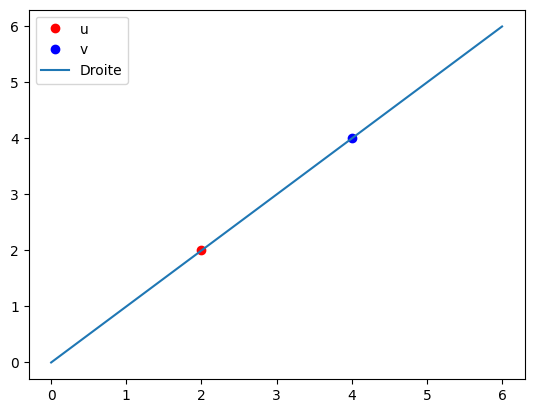

In [25]:
# On affiche les points
plt.plot(u[0], u[1], 'ro', label='u')
plt.plot(v[0], v[1], 'bo', label='v')
# On affiche la droite
def f(abs,m):
    a = m[0]
    b = m[1]
    y = a*abs+b
    return y
abscisses = [0, 1, 2, 3, 5, 6]
ordonnees = [f(x, m) for x in abscisses]
plt.plot(abscisses, ordonnees, '-', label='Droite')
plt.legend()
plt.show()

## Partie b - Ajustement approché
Exemple d'une droite avec plusieurs points

In [7]:
# Points au hasard pour exemples
x_data = np.array([1, 2, 3, 4, 5, 6])
y_data = np.array([2.2, 3.8, 6.5, 9.0, 10.5, 13.1])

# Construction de la matrice X
n = len(x_data)
X = np.column_stack((x_data, np.ones(n)))

# Calcul de m̂
X_transpose = X.T
m_chapeau = np.linalg.inv(X_transpose @ X) @ X_transpose @ y_data

a, b = m_chapeau
print("Paramètres : a = " + str(a) + ", b = " + str (b))

# Prédiction des valeurs pour tracer la droite
y_pred = X @ m_chapeau 

Paramètres : a = 2.202857142857144, b = -0.19333333333333602


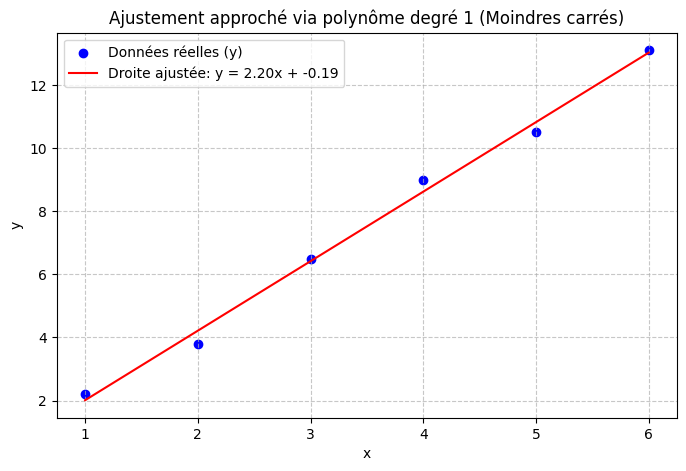

In [8]:
# Affichage
plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, color='blue', label='Données réelles (y)')
plt.plot(x_data, y_pred, color='red', label=f'Droite ajustée: y = {a:.2f}x + {b:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ajustement approché via polynôme degré 1 (Moindres carrés)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Partie c - Ajustement pour degré quelconque
Exemple d'une courbe avec plusieurs points

In [4]:
# On définit les points 
u = (1,2)
v = (2,5)
w = (4,4)
# On définit nos matrices
x = np.array([[0, 0, 1], [0, 0, 1], [0, 0, 1]])
x[0][0] = u[0]**2
x[0][1] = u[0]
x[1][0] = v[0]**2
x[1][1] = v[0]
x[2][0] = w[0]**2
x[2][1] = w[0]
y = np.array([0, 0, 0])
y[0] = u[1]
y[1] = v[1]
y[2] = w[1]
# Affichage pour vérifs
print(x)
print(y)

[[ 1  1  1]
 [ 4  2  1]
 [16  4  1]]
[2 5 4]


In [5]:
# Calcul de m̂
x_transpose = x.T
m_chapeau = np.linalg.inv(x_transpose @ x) @ x_transpose @ y

a, b, c = m_chapeau
print("Paramètres : a = " + str(a) + ", b = " + str (b) + ", c = " + str(c))

# Prédiction des valeurs pour tracer la droite
y_pred = x @ m_chapeau 

Paramètres : a = -1.1666666666666434, b = 6.49999999999989, c = -3.333333333333199


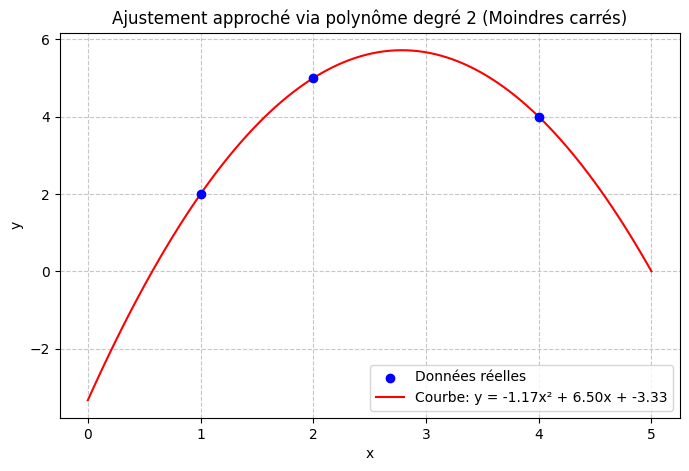

In [6]:
# Affichage

x_points = x[:, 1] # On récupère juste les abscisses
x_courbe = np.linspace(min(x_points) - 1, max(x_points) + 1, 100) # On crée 100 points
y_courbe = a * x_courbe**2 + b * x_courbe + c # Calcul de la courbe

plt.figure(figsize=(8, 5))
plt.scatter(x_points, y, color='blue', zorder=5, label='Données réelles')
plt.plot(x_courbe, y_courbe, color='red', label=f'Courbe: y = {a:.2f}x² + {b:.2f}x + {c:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ajustement approché via polynôme degré 2 (Moindres carrés)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Question 5 - dim 3

In [ ]:
# Construction du plan 
z = a*x + b*y + c
# Gemini :
X_plan = np.column_stack((x, y, np.ones(len(x))))
m_plan = np.linalg.inv(X_plan.T @ X_plan) @ X_plan.T @ z

LinAlgError: Singular matrix

# Partie d - Régression
Exemple d'une courbe de degré 4

In [27]:
# Lecture des csv
x_data = pd.read_csv('x.csv', header=None).values.flatten()
y_data = pd.read_csv('y.csv', header=None).values.flatten()
n = len(x_data)


np.random.seed(42)
indices = np.random.permutation(n)
x_data, y_data = x_data[indices], y_data[indices]

# Génération du polynome
def matrice_polynomiale(x, degre):
    return np.column_stack([x**i for i in range(degre, -1, -1)])


degres_a_tester = [1, 2, 3, 4, 5, 6, 7]
erreurs_moyennes = []

K = 4                
taille_bloc = n // K 

print("Évaluation des polynômes par Validation Croisée :")
print("Degré | Erreur Test Moyenne (MSE)")

Évaluation des polynômes par Validation Croisée :
Degré | Erreur Test Moyenne (MSE)


In [28]:
for d in degres_a_tester:
    erreurs_du_degre = []
    
    for i in range(K):

        indices_test = list(range(i * taille_bloc, (i + 1) * taille_bloc))
        indices_train = [idx for idx in range(n) if idx not in indices_test]
        
        x_train, y_train = x_data[indices_train], y_data[indices_train]
        x_test, y_test = x_data[indices_test], y_data[indices_test]
        
        X_train = matrice_polynomiale(x_train, d)
        X_test = matrice_polynomiale(x_test, d)
        
        try:
            m_chapeau = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
            
            y_pred = X_test @ m_chapeau
            
            erreur = np.mean((y_test - y_pred)**2)
            erreurs_du_degre.append(erreur)
        except np.linalg.LinAlgError:
            erreurs_du_degre.append(np.inf)
            
    erreur_moyenne = np.mean(erreurs_du_degre)
    erreurs_moyennes.append(erreur_moyenne)
    print("  " + str(d) + "   | " +   str(erreur_moyenne))

  1   | 14.99878471906187
  2   | 22.07013837552176
  3   | 9.32019544661663
  4   | 3.2184661354224033
  5   | 7.067730985906701
  6   | 48.521944319623586
  7   | 9.204102013739345


Le polynôme qui GÉNÉRALISE le mieux est de DEGRÉ 4


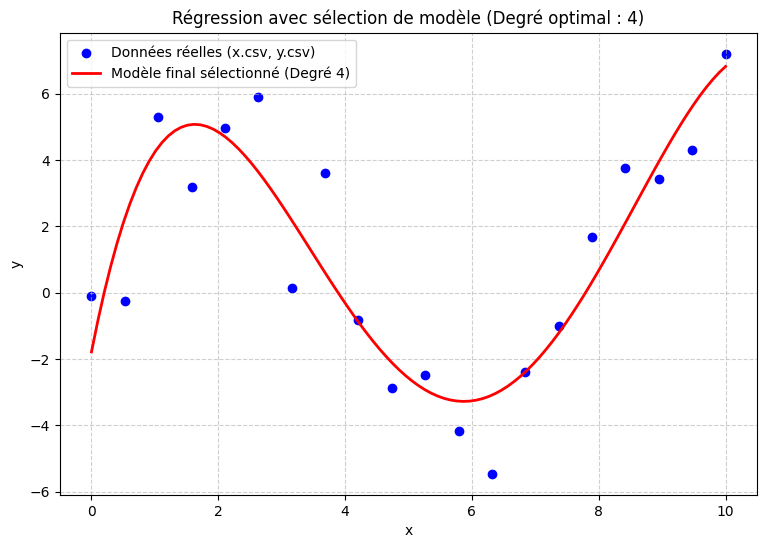

In [29]:
meilleur_degre = degres_a_tester[np.argmin(erreurs_moyennes)]
print("Le polynôme qui GÉNÉRALISE le mieux est de DEGRÉ "  + str(meilleur_degre))

X_complet = matrice_polynomiale(x_data, meilleur_degre)
m_final = np.linalg.inv(X_complet.T @ X_complet) @ X_complet.T @ y_data

x_lisse = np.linspace(min(x_data), max(x_data), 100)
X_lisse = matrice_polynomiale(x_lisse, meilleur_degre)
y_lisse = X_lisse @ m_final

# Affichage
plt.figure(figsize=(9, 6))
plt.scatter(x_data, y_data, color='blue', label='Données réelles (x.csv, y.csv)')
plt.plot(x_lisse, y_lisse, color='red', linewidth=2, label=f'Modèle final sélectionné (Degré {meilleur_degre})')
plt.title(f'Régression avec sélection de modèle (Degré optimal : {meilleur_degre})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()